In [2]:
#a)

import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, 400)
#plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
#plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
#plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
#plt.show()




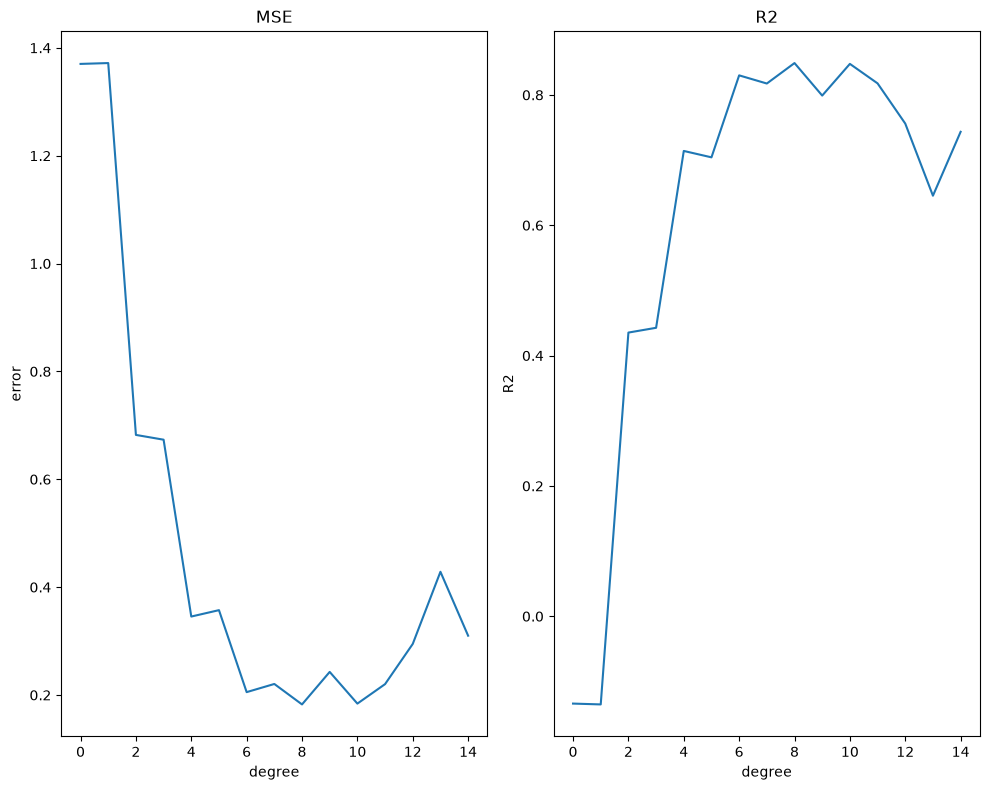

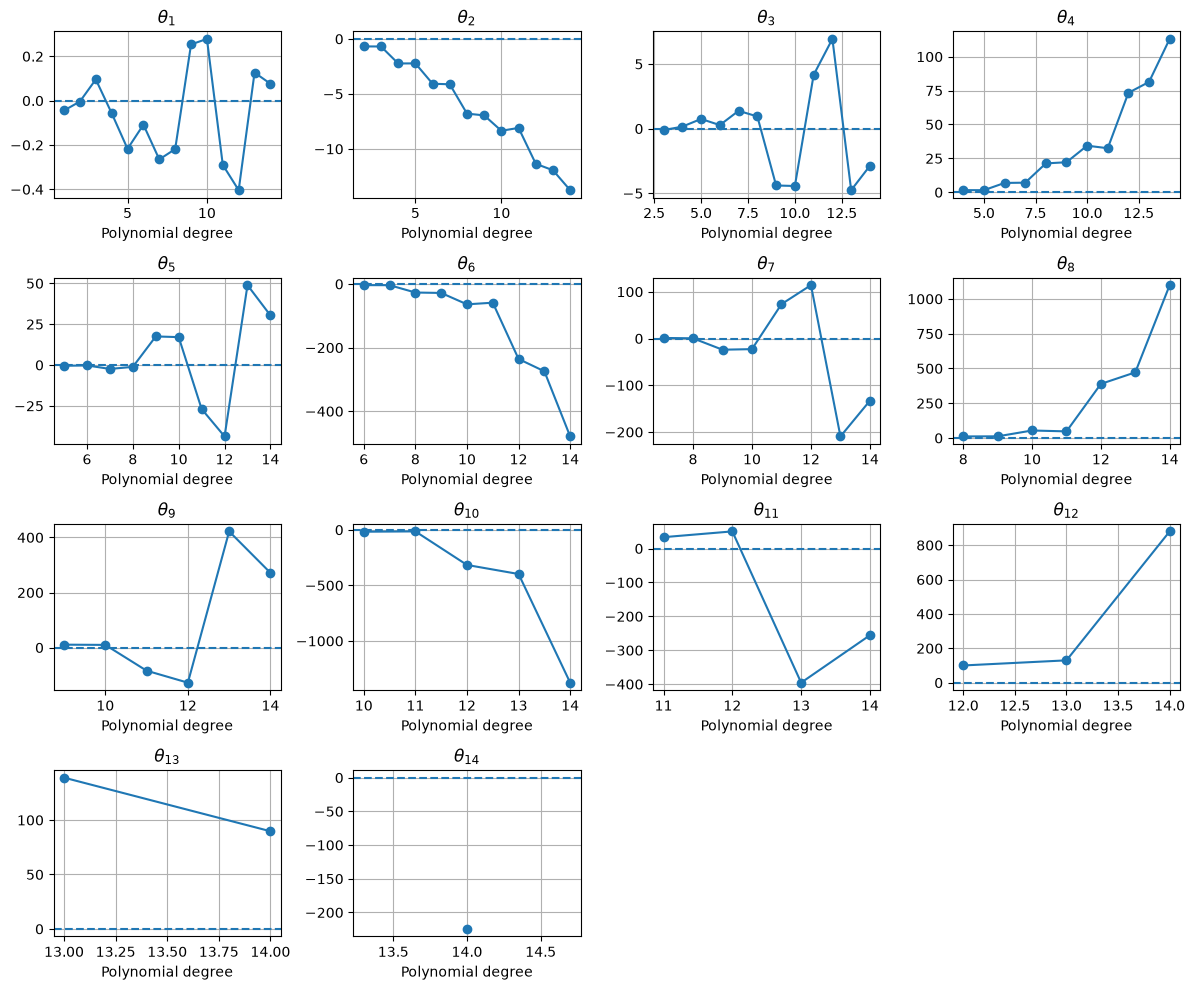

MSE coeffs polynomial degree 5: [-0.020156102051171566, -0.21725503045423158, -2.2266958782468094, 0.7504325845647202, 1.5673192141652652, -0.4540749631354588]


In [3]:
from sklearn.model_selection import train_test_split

maxdegree = 15
degrees = np.arange(maxdegree)
MSE = np.zeros(maxdegree)
R2 = np.zeros(maxdegree)

coeffs = [np.zeros(maxdegree-i) for i in range(maxdegree)]
y_std = (y-np.mean(y))/np.sqrt(np.var(y))


for degree in degrees:
    X = design_matrix(x, degree)
    X_mean = X - np.mean(X, axis = 0, keepdims = True)
    X_std = np.empty((n, degree+1))
    X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
    X_std[:,0] = np.ones(n)

    Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

    coeff = np.zeros(degree+1)

    U, s, Vt = np.linalg.svd(Xtrain)


    s_inv = np.zeros((degree+1,len(Ytrain)))
    s_inv[:,:degree+1] += np.diag(1/s)
    coeff = Vt.T@s_inv@U.T@Ytrain

    for i in range(degree+1):
        coeffs[i][degree-i] = coeff[i]

    y_pred = Xtest@coeff

    y_mean = np.mean(Ytest)

    MSE[degree] = np.mean((y_pred-Ytest)**2)
    R2[degree] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

#plt.plot(degrees, MSE)
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].plot(degrees,MSE)
axes[0].set_title("MSE")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("error")

axes[1].plot(degrees,R2)
axes[1].set_title("R2")
axes[1].set_xlabel("degree")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.plot()
plt.show()


#plotter koeffesientene unntat intercept fordi det er alltid 0
#----!!! KODE her laget av ChatGPT !!!----:
# Plot each coefficient separately
square = int(np.sqrt(maxdegree))+1
fig, axes = plt.subplots(
    square, square,
    figsize=(12, 10)
)

axes = axes.flatten()

for i in range(1, maxdegree):
    degrees_i = np.arange(i, maxdegree)

    axes[i - 1].plot(
        degrees_i,
        coeffs[i],
        marker="o",
        linestyle="-"
    )

    axes[i - 1].axhline(0, linestyle="--")

    axes[i - 1].set_title(rf"$\theta_{{{i}}}$")
    axes[i - 1].set_xlabel("Polynomial degree")
    axes[i - 1].grid(True)

# Hide the unused subplot
for j in range(maxdegree - 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
#----------------------------------------
coeffs_degree_5 = [float(coeffs[i][5-i]) for i in range(6)]
print("MSE coeffs polynomial degree 5:", coeffs_degree_5)


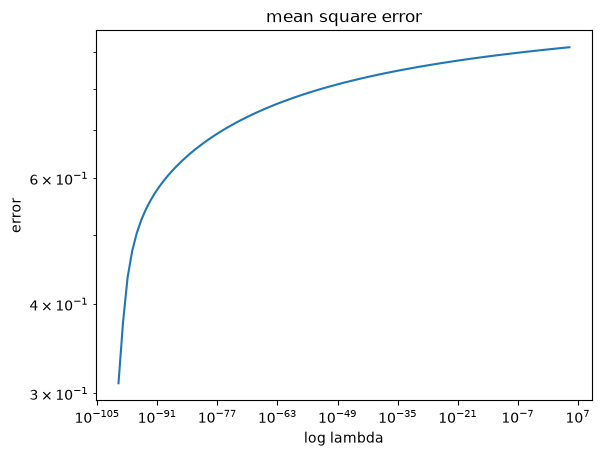

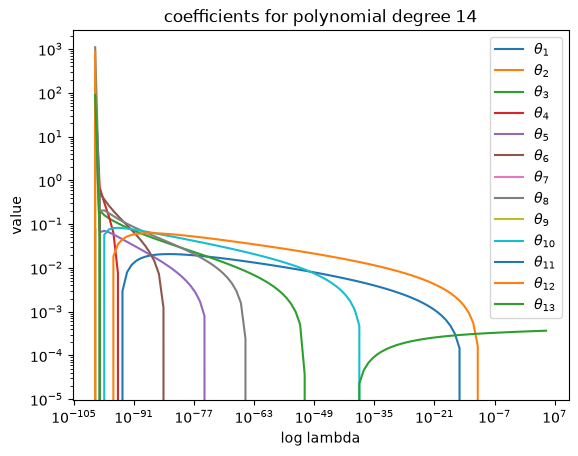

min mse:  0.30999668849625467
lambda:  1e-100


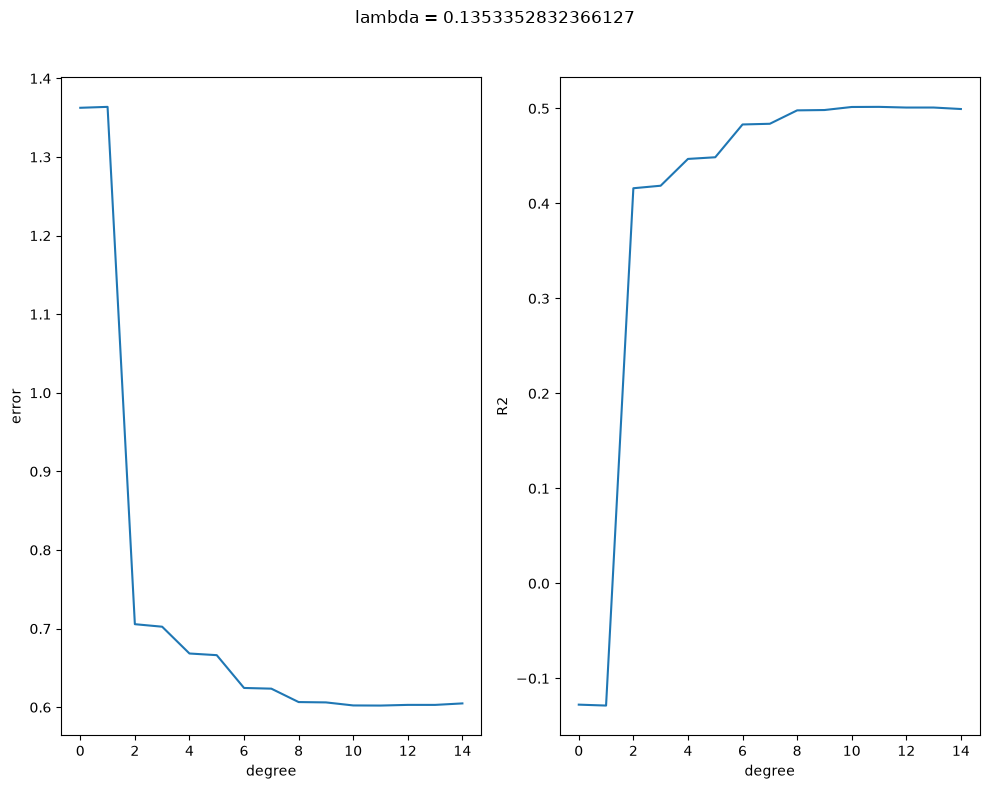

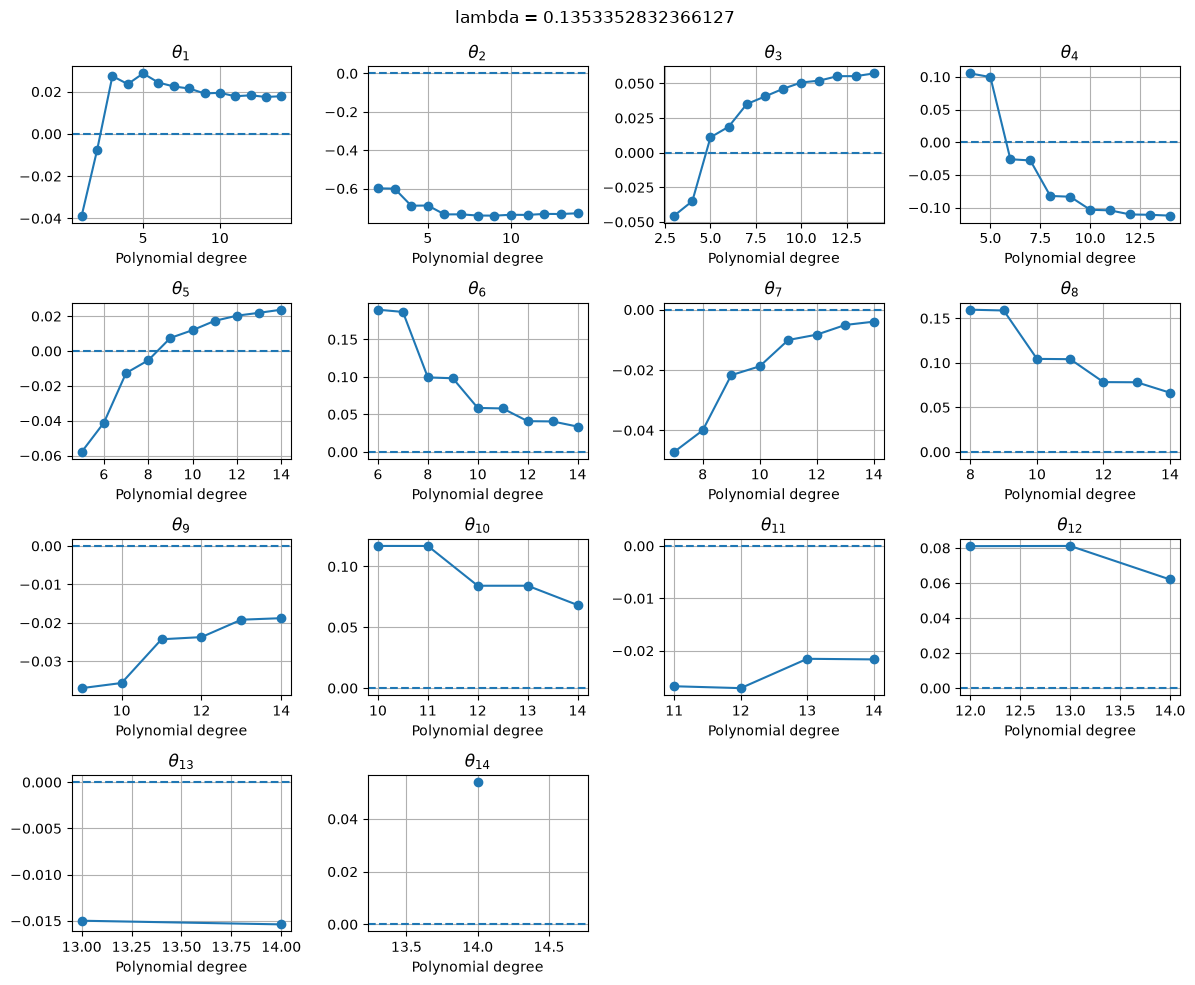

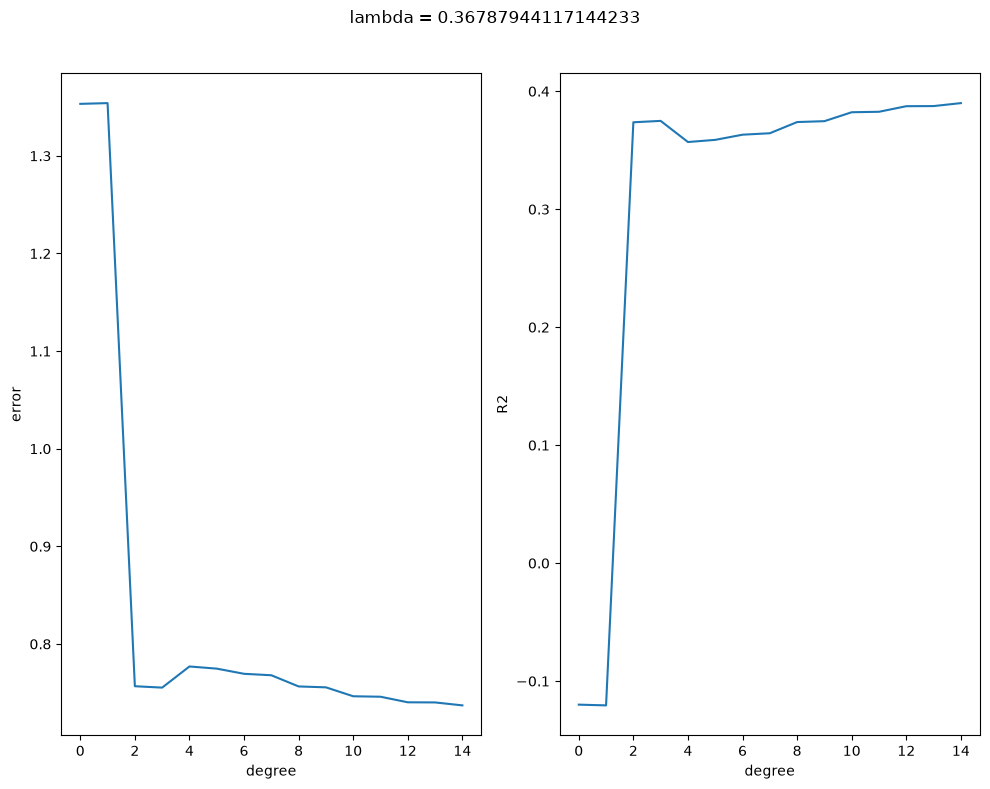

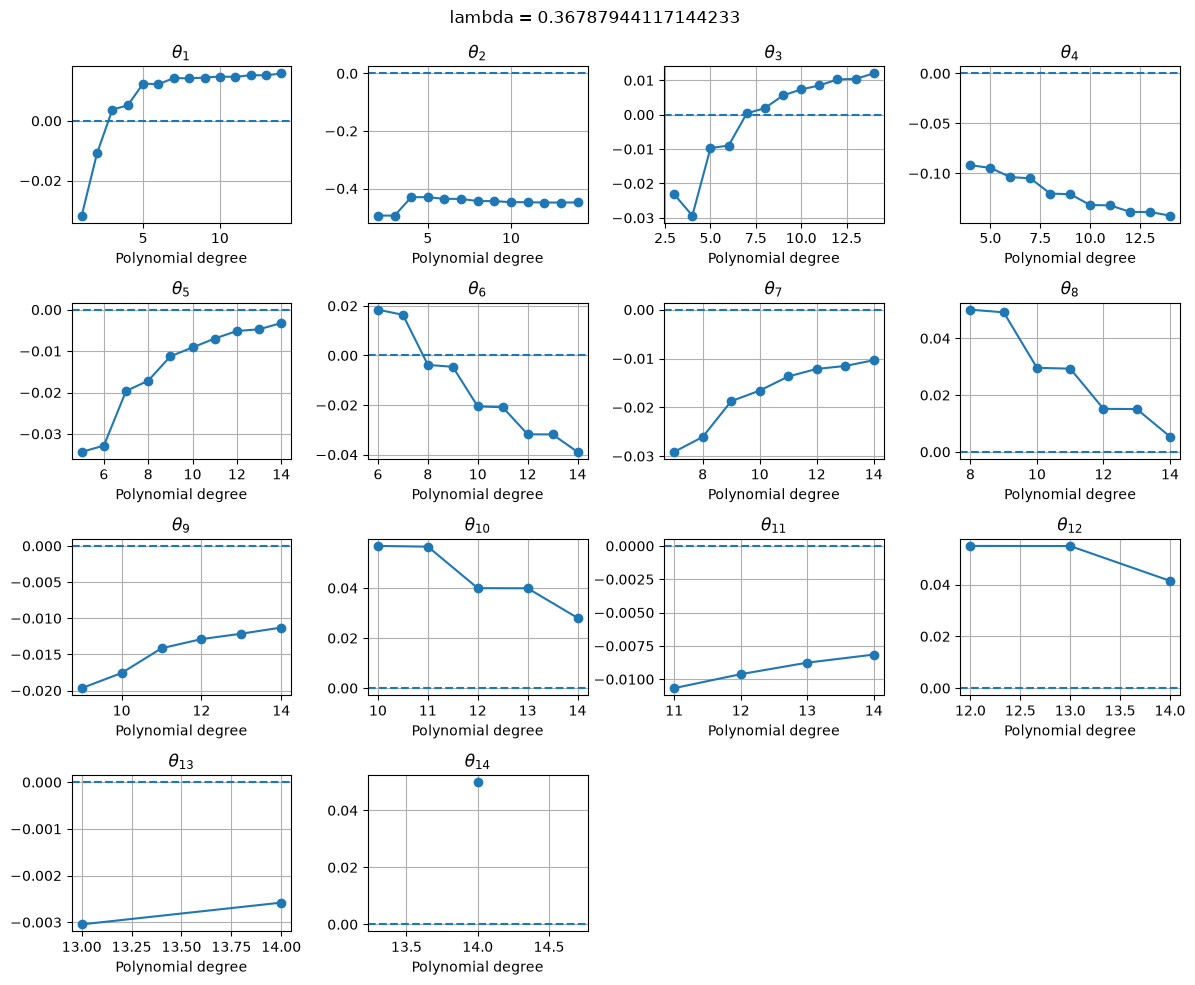

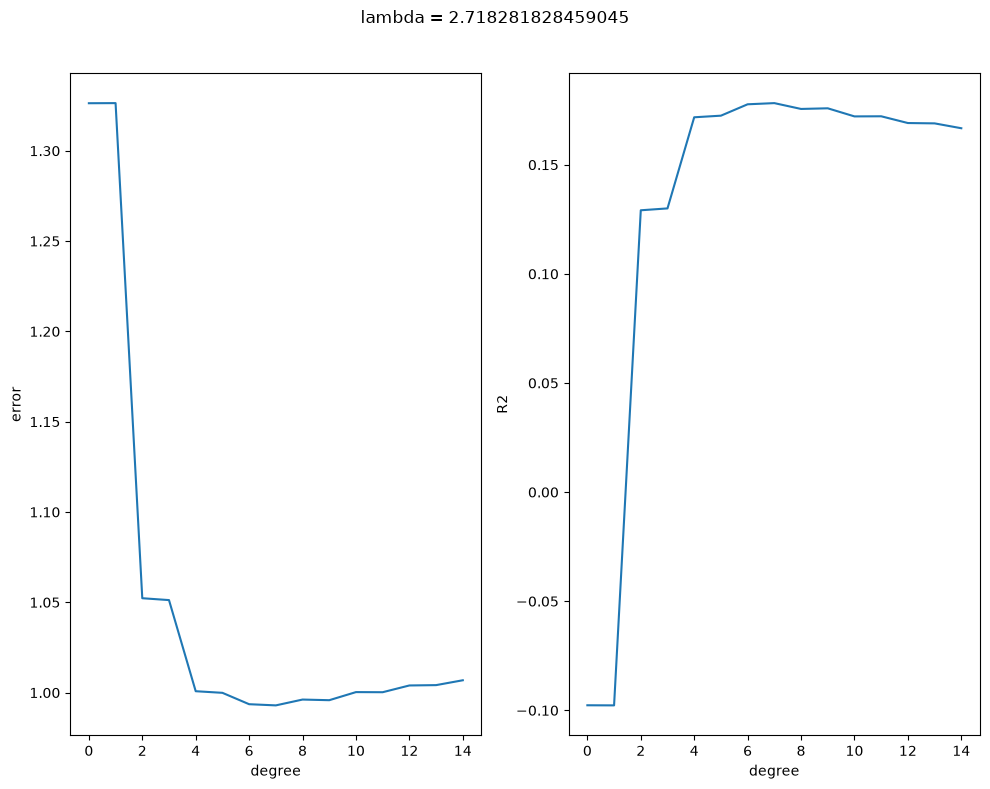

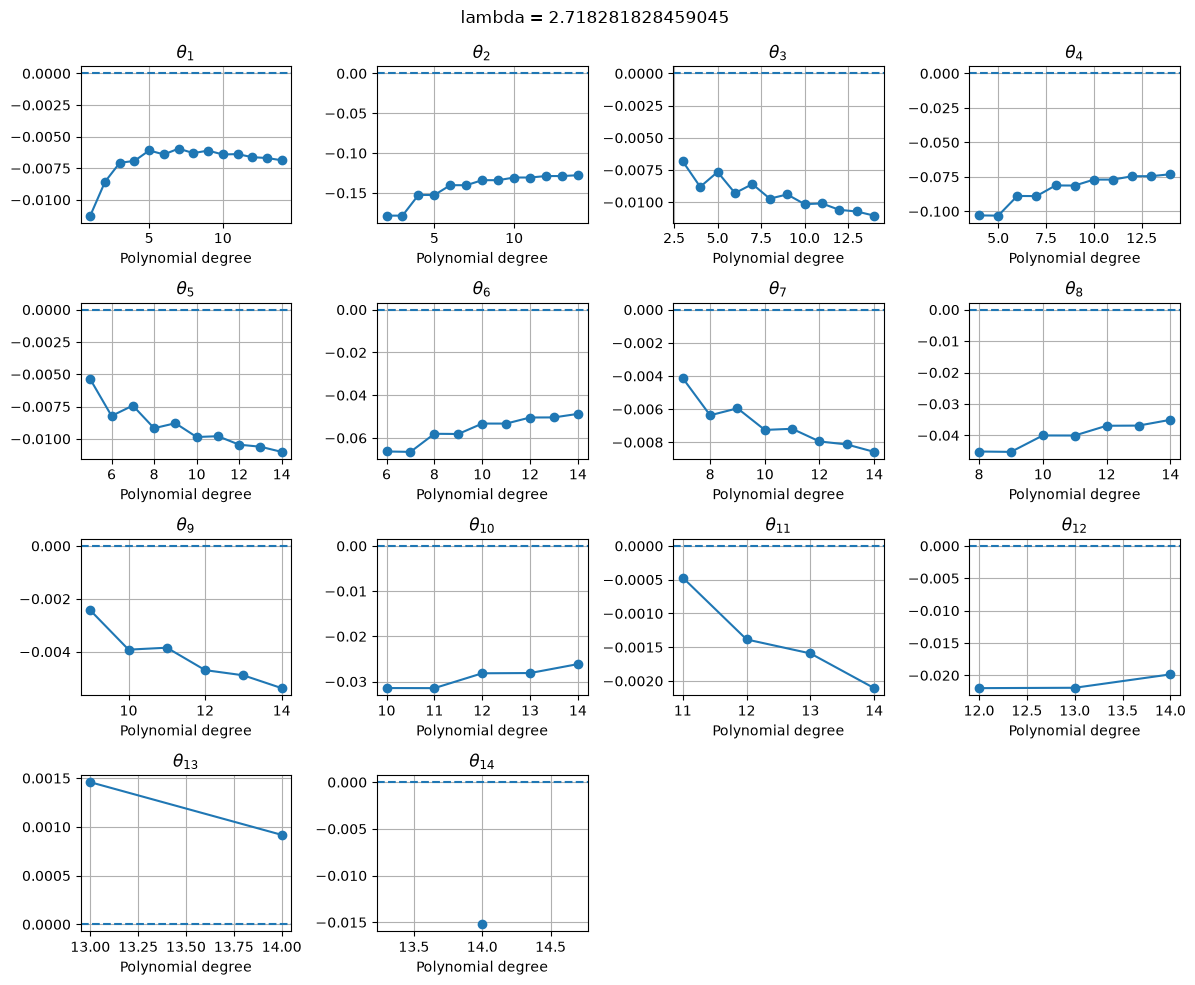

[ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]


In [4]:
#b
n = 100

degree = 14

X = design_matrix(x, degree)
X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state=2026)

n_train = len(Xtrain[:,0])

lambda_num = 100
lam_borders = -5,5
lam = np.logspace(-100, 5, lambda_num)

train_len = len(Ytrain)

MSE = np.zeros(lambda_num)
R2  = np.zeros(lambda_num)

coeffs = np.zeros((lambda_num, degree+1))

for l in range(lambda_num):

    se = 0

    U, s, Vt = np.linalg.svd(Xtrain)
    s2= np.diag(s**2)
    inv_mat = Vt.T@s2@Vt+np.identity(degree+1)*l
    coeff = np.linalg.solve(inv_mat, Xtrain.T@Ytrain)
    y_pred = Xtest@coeff
    
    y_mean = np.mean(Ytest)

    coeffs[l] = coeff

    MSE[l] = np.mean((y_pred-Ytest)**2)
    R2[l] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

plt.plot(lam, MSE)
plt.title("mean square error")
plt.ylabel("error")
plt.xlabel("log lambda")
plt.yscale("log")
plt.xscale("log")
plt.show()

for i in range(1,degree):
    plt.plot(lam, coeffs[:,i])
plt.title("coefficients for polynomial degree 14")
plt.ylabel("value")
plt.xlabel("log lambda")
plt.yscale("log")
plt.xscale("log")
plt.legend([r"$\theta_{"+str(i+1)+"}$" for i in range(degree)])
plt.show()

print("min mse: ",np.min(MSE))
print("lambda: ",lam[np.argmin(MSE)])


"""

HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH

"""

maxdegree = 15
degrees = np.arange(maxdegree)
loglambdas = np.array([-2,-1,1])

lambdas = np.exp(loglambdas)

recorded_coeff = np.zeros(6)

for j,l in enumerate(lambdas):
    MSE = np.zeros(maxdegree)
    R2 = np.zeros(maxdegree)

    coeffs = [np.zeros(maxdegree-i) for i in range(maxdegree)]
    y_std = (y-np.mean(y))/np.sqrt(np.var(y))


    for degree in degrees:
        X = design_matrix(x, degree)
        X_mean = X - np.mean(X, axis = 0, keepdims = True)
        X_std = np.empty((n, degree+1))
        X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
        X_std[:,0] = np.ones(n)

        Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state=2026)

        coeff = np.linalg.solve(Xtrain.T@Xtrain+np.identity(degree+1)*l*n_train, Xtrain.T@Ytrain)
        y_pred = Xtest@coeff

        for i in range(degree+1):
            coeffs[i][degree-i] = coeff[i]

        y_pred = Xtest@coeff

        y_mean = np.mean(Ytest)

        MSE[degree] = np.mean((y_pred-Ytest)**2)
        R2[degree] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

        if degree == 5 and j == 0:
            recorded_coeff = coeff


    #plt.plot(degrees, MSE)
    fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    axes[0].plot(degrees,MSE)
    axes[0].set_xlabel("degree")
    axes[0].set_ylabel("error")

    axes[1].plot(degrees,R2)
    axes[1].set_xlabel("degree")
    axes[1].set_ylabel("R2")

    fig.suptitle("lambda = "+str(l))#<---- Disse to linjene er fra ChatGPT
    plt.tight_layout(rect=[0, 0, 1, 0.96]) #<--- og her
    plt.plot()
    plt.show()


    #plotter koeffesientene unntat intercept fordi det er alltid 0
    #----!!! KODE her laget av ChatGPT !!!----:
    # Plot each coefficient separately
    square = int(np.sqrt(maxdegree))+1
    fig, axes = plt.subplots(
        square, square,
        figsize=(12, 10)
    )

    axes = axes.flatten()

    for i in range(1, maxdegree):
        degrees_i = np.arange(i, maxdegree)

        axes[i - 1].plot(
            degrees_i,
            coeffs[i],
            marker="o",
            linestyle="-"
        )

        axes[i - 1].axhline(0, linestyle="--")

        axes[i - 1].set_title(rf"$\theta_{{{i}}}$")
        axes[i - 1].set_xlabel("Polynomial degree")
        axes[i - 1].grid(True)

    # Hide the unused subplot
    for j in range(maxdegree - 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.suptitle("lambda = "+str(l))
    plt.show()
    #----------------------------------------
print(recorded_coeff)



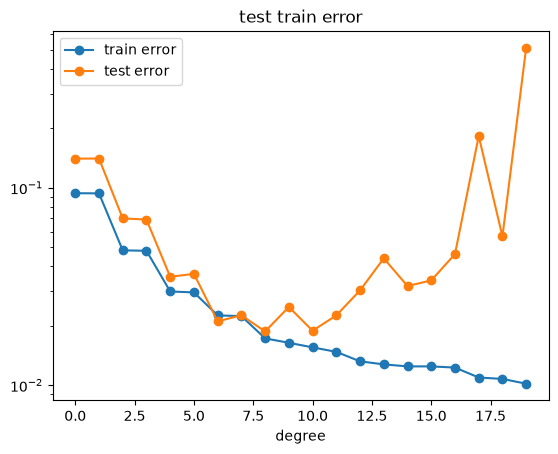

In [5]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2, random_state=2026)
from sklearn.metrics import mean_squared_error

maxdegree = 20
train_error = np.zeros(maxdegree)
test_error = np.zeros(maxdegree)
for degree in range(maxdegree):
    Xtrain = design_matrix(xtrain, degree)

    coeff = np.zeros(degree+1)

    U, s, Vt = np.linalg.svd(Xtrain)
    s_inv = np.zeros((degree+1,len(Ytrain)))
    s_inv[:,:degree+1] += np.diag(1/s)
    coeff = Vt.T@s_inv@U.T@ytrain #<-- ChatGPT fikset en bug her, der jeg hadde skrevet Ytrain i stedet.

    Xtest = design_matrix(xtest, degree)
    y_pred_test = Xtest@coeff
    y_pred_train = Xtrain@coeff

    test_error[degree] = mean_squared_error(y_pred_test, ytest)
    train_error[degree] = mean_squared_error(y_pred_train, ytrain)

degrees = np.arange(maxdegree)
plt.plot(degrees, train_error, marker = "o", linestyle ="-")
plt.plot(degrees, test_error, marker = "o", linestyle = "-")
plt.legend(["train error", "test error"])
plt.xlabel("degree")
plt.yscale("log")
plt.title("test train error")
plt.show()



$$
\mathbb{E}((y-\tilde{y})^2) = \mathbb{E}((y-\mathbb{E}(\tilde{y}))-(\tilde{y}-\mathbb{E}(\tilde{y}))^2)\\
=\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}((y-\mathbb{E}(\tilde{y}))(\tilde{y}-\mathbb{E}(\tilde{y}))=\\ \mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}(y-\mathbb{E}(\tilde{y}))\mathbb{E}(\tilde{y}-\mathbb{E}(\tilde{y}))=\\ \mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}(y-\mathbb{E}(\tilde{y}))(\mathbb{E}(\tilde{y})-\mathbb{E}(\tilde{y}))=\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)
$$
Jeg ser nå på $\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)$:

$$
\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)=\mathbb{E}((f+\epsilon-\mathbb{E}[\tilde{y}])^2)=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2+\epsilon^2+2\epsilon(f-\mathbb{E}[\tilde{y}])] =\\ \mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]+2\mathbb{E}[\epsilon(f-\mathbb{E}[\tilde{y}])]=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]+2\mathbb{E}[\epsilon]\mathbb{E}[(f-\mathbb{E}[\tilde{y}])]=\\
\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\sigma^2
$$

Hvis jeg nå setter alt sammen:
$$
\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)=\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\sigma^2 \\ =\frac{1}{n}\sum_i(f_i-\mathbb{E}(\tilde{y}))^2+\frac{1}{n}\sum_i(\tilde{y}_i-\mathbb{E}(\tilde{y}))^2+\sigma^2
$$

Jeg ser på hva som skjer om man erstatter f med y i bias leddet:

$$
\mathbb{E}[((y_{test})-\tilde{y})^2] = \mathbb{E}[(f+\sigma+\tilde{y})]^2 =\\ \mathbb{E}[(f+\tilde{y})^2]+\mathbb{E}[\sigma^2]+2\mathbb{E}[(f+\tilde{y})\sigma] = \mathbb{E}[(f+\tilde{y})^2]+E[\sigma^2]+2E[(f+\tilde{y})]\mathbb{E}[\sigma] =  \mathbb{E}[(f+\tilde{y})^2]+\sigma^2
$$

Dermed kan man se at Bias slik den er definert med $y_{test}$ i stedet for $f$ blir større på grunn av $\sigma$, så den printete identiteten kommer er ikke lik i teorien.

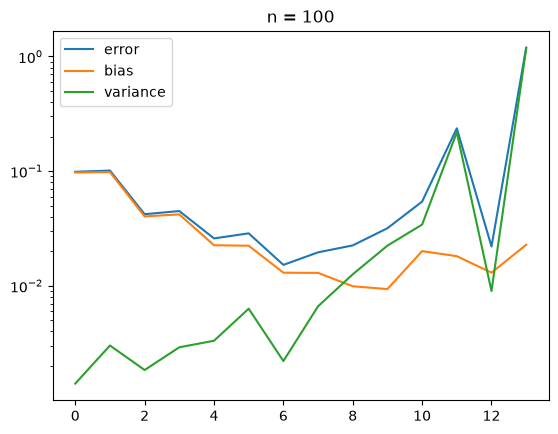

min error:  0.015214919544904651
degree with min error:  6


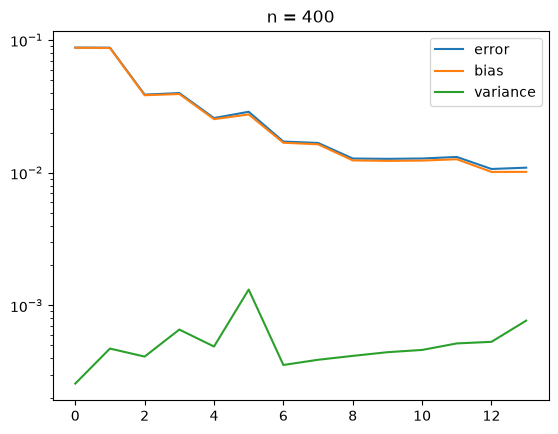

min error:  0.010683478715911278
degree with min error:  12


In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample

np.random.seed(2026)
ns = [100, 400]
n_bootstraps, maxdegree = 100, 14

for n in ns:
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)

    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state= 2026)

    x_train = x_train.reshape(-1,1)
    x_test = x_test.reshape(-1,1)

    error = np.zeros(maxdegree)
    bias = np.zeros(maxdegree)
    variance = np.zeros(maxdegree)

    for deg in range(maxdegree):
        model = make_pipeline(PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))

        y_pred = np.empty((len(y_test), n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:,i] = model.fit(x_,y_).predict(x_test).ravel()

        error[deg] = np.mean(np.mean((y_test[:, None]-y_pred)**2, axis = 1))#<- ChatGPT fikset indekserings feil
        bias[deg] = np.mean((y_test - np.mean(y_pred, axis = 1))**2)#<- ChatGPT fikset indekseringsfeil her.
        variance[deg] = np.mean(np.var(y_pred, axis = 1))
        

    x_axis = np.arange(maxdegree)
    plt.yscale("log")
    plt.title("n = "+str(n))
    plt.plot(x_axis, error)
    plt.plot(x_axis, bias)
    plt.plot(x_axis, variance)
    plt.legend(["error","bias", "variance"])


    plt.show()
    print("min error: ",np.min(error))
    print("degree with min error: ",np.argmin(error))


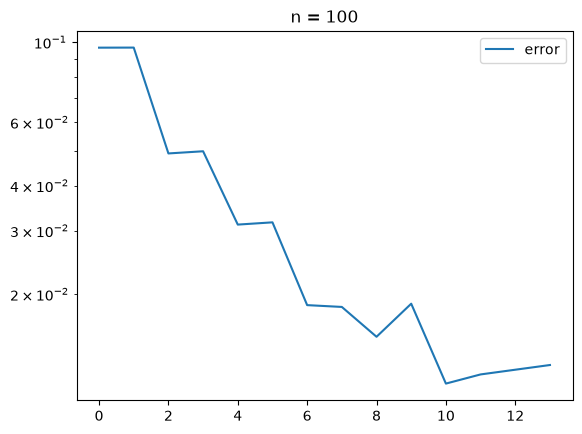

min error:  0.01128922344719185
degree with min error:  10


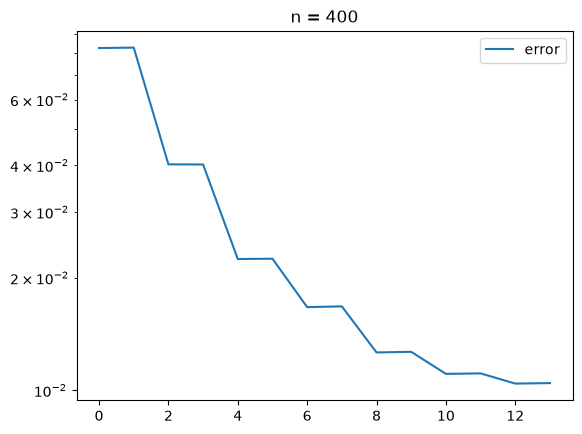

min error:  0.010419013932380917
degree with min error:  12


In [7]:
#d
from sklearn.model_selection import train_test_split, KFold, cross_val_score

np.random.seed(2026)
ns = [100,400]
maxdegree = 14
splits = 10
for n in ns:
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)

    kf = KFold(n_splits = splits, shuffle = True, random_state=2026)

    MSE = np.zeros(maxdegree)

    for deg in range(maxdegree):
        mse = np.zeros(splits)

        model = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept= False))

        for i, (train_idx, test_idx) in enumerate(kf.split(x)):
            y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
            y_test = y[test_idx]

            mse[i] = np.mean((y_pred-y_test)**2)

        MSE[deg] = np.mean(mse)

    x_axis = np.arange(maxdegree)
    plt.yscale("log")
    plt.title("n = "+str(n))
    plt.plot(x_axis, MSE)
    plt.legend(["error","bias", "variance"])


    plt.show()
    print("min error: ",np.min(MSE))
    print("degree with min error: ",np.argmin(MSE))

In [8]:
#Gradients:
#This was taken from the project task page:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy
from jax import grad

degree, lmbda = 5, 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())
n=n

OLS   max |AD - analytic| = 1.1102230246251565e-15
Ridge max |AD - analytic| = 1.1102230246251565e-15
eta_max for OLS  = 0.83289897114146


In [9]:
#e
n=100 #<- ChatGPT fikset koden med å flytte n
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

X = design_matrix(x, degree)

X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain


n_train = len(X_norm5[:,0])

n_features5 = X_norm5.shape[1]

Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])


# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 100000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


# Initialize weights for gradient descent

recorded_theta_OLS = np.zeros(n_features5)

#OLS
# Gradient descent loop
gamma = gamma_opt

theta_gdOLS = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma_opt*grad_OLS
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS = t

#Ridge:

Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])


# Gradient descent loop
theta_gdRidge = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - gamma_opt_Ridge*grad_Ridge
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for gamma: ",int(actual_iters_OLS))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for gamma: ",int(actual_iters_Ridge))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

OLS:
theta: [-0.0201561  -0.21725501 -2.22669588  0.75043252  1.56731922 -0.45407491]
iterations for gamma:  3952
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]
iterations for gamma:  154
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413


In [10]:
#e jax
n=100

rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

X = design_matrix(x, degree)

print(np.shape(X))
X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain


n_train = len(X_norm5[:,0])

n_features5 = X_norm5.shape[1]

Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])


# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 5000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


# Initialize weights for gradient descent


recorded_theta_OLS = np.zeros(n_features5)

#OLS
# Gradient descent loop
gamma = gamma_opt

theta_gdOLS = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_OLS = grad_OLS = grad(cost_ols)(theta_gdOLS, jnp.asarray(X_norm5), jnp.asarray(Ytrain))
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma_opt*grad_OLS
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS = t

#Ridge:

Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])


# Gradient descent loop
theta_gdRidge = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_Ridge = grad(cost_ridge)(theta_gdRidge, jnp.asarray(X_norm5), jnp.asarray(Ytrain), lam)#<- ChatGPT fant bug her, jeg hadde skrevet theta_gdOLS i stedet for Ridge
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - gamma_opt_Ridge*grad_Ridge
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for gamma: ",int(actual_iters_OLS))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for gamma: ",int(actual_iters_Ridge))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

(100, 6)
OLS:
theta: [-0.0201561  -0.21725501 -2.22669588  0.75043252  1.56731922 -0.45407491]
iterations for gamma:  3952
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]
iterations for gamma:  154
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413


In [11]:
#f
n=100
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

X = design_matrix(x, degree)

X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain


n_train = len(X_norm5[:,0])

n_features5 = X_norm5.shape[1]

Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])

# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 100000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


#Momentum:
gamma = gamma_opt*0.9
beta = 0.9
v = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    v = beta*v + gamma*grad_OLS
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - v
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_momentum = t

#AdaGrad:
eps = 0.0001
r = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    r = r + grad_OLS**2
    # Update parameters theta
    theta_gdOLS = theta_gdOLS -(gamma*grad_OLS)/np.sqrt(eps+r)
    if np.linalg.norm(grad_OLS)<tol:
        break
actual_iters_OLS_AdaGrad = t

#RMSProp
gamma = 100
rho = 0.1
eps = 0.0001
r = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    r = rho*v + (1-rho)*grad_OLS**2
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma*grad_OLS/(np.sqrt(r)+eps) #<- ChatGPT påpekte at jeg hadde skrevet oppdateringen her feil
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_RMSProp = t

#Adam
beta1 = 0.9
beta2 = 0.999
eps = 0.0001
theta_gdOLS = np.zeros(n_features5)
m = np.zeros(n_features5)
r = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    m = beta1*m + (1-beta1)*grad_OLS
    r = beta2*r + (1-beta2)*grad_OLS**2

    m_hat = m / (1.0 - beta1**t) 
    r_hat = r / (1.0 - beta2**t)
    theta_gdOLS = theta_gdOLS - gamma*m_hat/(np.sqrt(r_hat)+eps)
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_Adam = t

#Ridge:

Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])
gamma = 0.9*gamma_opt_Ridge

# Momentum:
theta_gdRidge = np.zeros(n_features5)
v = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    v = beta*v + gamma*grad_Ridge
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - v
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for momentum: ",int(actual_iters_OLS_momentum))
print("iterations for RMSProp: ",int(actual_iters_OLS_RMSProp))
print("iterations for AdaGrad: ",int(actual_iters_OLS_AdaGrad))
print("iterations for Adam: ",int(actual_iters_OLS_Adam))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for gamma: ",int(actual_iters_Ridge))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

OLS:
theta: [-0.0201561  -0.21725482 -2.22669588  0.75043187  1.56731924 -0.45407443]
iterations for momentum:  324
iterations for RMSProp:  100000
iterations for AdaGrad:  6206
iterations for Adam:  578
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957798 -0.05788124]
iterations for gamma:  339
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413


In [12]:
#Dette er modifisert fra koden fra ukesoppgavene uke 38
#De er modifisert av språkmodeller

import numpy as np
import matplotlib.pyplot as plt

def exercise_data(n=100, degree=2, sigma=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

#---------Skrevet av ChatGPT--------------------------
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):

    if method == "plain":
        return theta - gamma * g, state

    if method == "momentum":
        v = state.get("v", np.zeros_like(theta))
        v = beta * v + (1 - beta) * g
        state["v"] = v

        return theta - gamma*v, state

    if method == "adagrad":
        r = state.get("r", np.zeros_like(theta))
        r = r + g**2
        state["r"] = r

        return theta - gamma * g / np.sqrt(eps + r), state

    if method == "rmsprop":
        r = state.get("r", np.zeros_like(theta))
        r = rho * r + (1 - rho) * g**2
        state["r"] = r

        return theta - gamma * g / np.sqrt(r + eps), state

    if method == "adam":
        m = state.get("m", np.zeros_like(theta))
        r = state.get("r", np.zeros_like(theta))

        m = beta1 * m + (1 - beta1) * g
        r = beta2 * r + (1 - beta2) * g**2

        state["m"] = m
        state["r"] = r

        # Bias correction
        m_hat = m / (1 - beta1**t)
        r_hat = r / (1 - beta2**t)

        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state

    raise ValueError(f"unknown method {method}")
#------------------------------------------


def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

theta = np.zeros(2)
lbd = 0.01
gamma = 0.5
def grad_2(theta):
    return gradient(theta, X2, y2, lbd)

a,b = optimise(grad_2, theta, "momentum", gamma)
print(a[-1])
print(closed_form(X2, y2, lbd))



degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354
[ 0.04750049 -0.23421919]
[ 0.04750049 -0.23421919]


c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:28: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:28: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:28: RuntimeWarning: invalid value encountered in multiply
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2804: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, 

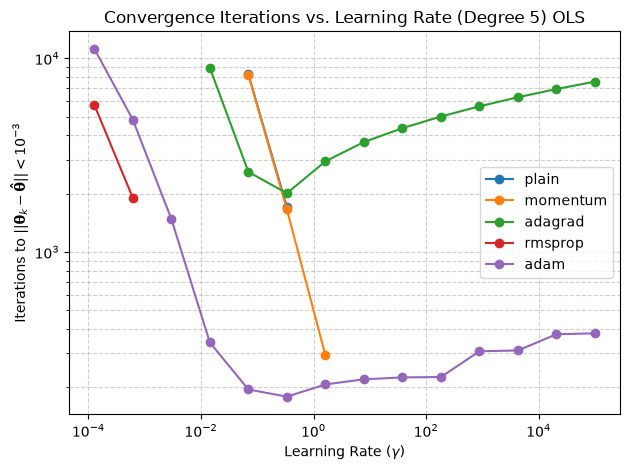

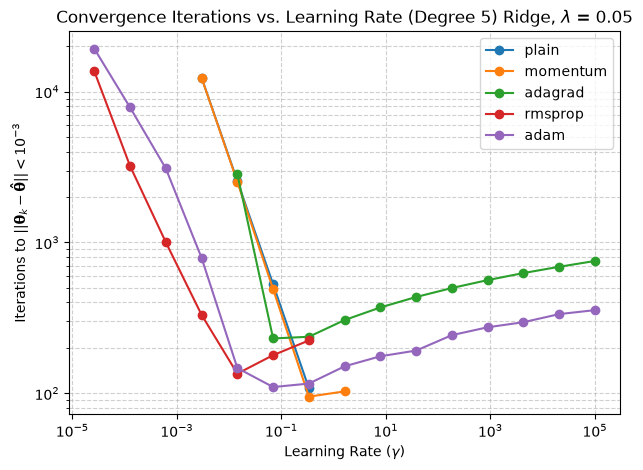

In [13]:
num = 20
gammas = np.logspace(-8,5,num)


#Resten skrevet av gemini med litt input fra meg:
lambdas = [0, 0.05]
types = ["OLS", r"Ridge, $\lambda$ = "+str(lambdas[1])]

max_iters = 20000
target_tol = 1e-3
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

for lbd, regression_type in zip(lambdas, types):
    grad_5_fn = lambda theta: gradient(theta, X5, y5, lam=lbd)
    theta_exact_5 = closed_form(X5, y5, lbd)
    for method in methods:
        iterations_to_target = np.zeros(num)
        
        for i, gamma in enumerate(gammas):
            theta0 = np.zeros(X5.shape[1])
            
            # Run full optimization budget without stopping on gradient tolerance
            history, _ = optimise(grad_5_fn, theta0, method, gamma, num_iters=max_iters, tol=0)
            
            # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
            distances = np.linalg.norm(history - theta_exact_5, axis=1)
            
            # Find first iteration step reaching the threshold
            converged_steps = np.where(distances < target_tol)[0]
            
            if len(converged_steps) > 0:
                iterations_to_target[i] = converged_steps[0]
            else:
                # Set to max_iters (or np.nan) to indicate non-convergence
                iterations_to_target[i] = np.nan

        plt.loglog(gammas, iterations_to_target, marker="o", label=method)

    plt.xlabel(r"Learning Rate ($\gamma$)")
    plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
    plt.title("Convergence Iterations vs. Learning Rate (Degree 5) "+regression_type)
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

The plot shows the number of iterations for the methods to converge for different

In [14]:
# What does AD say about d|theta|/dtheta at theta = 0?  (Discuss whether this is a valid subgradient.)
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))

# Your Lasso code for part g) here

jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0


This does not make sense for the derivative of |0.0| the program says 1.0, but the derivative is not defined here. if i look at the definition going in different directions: $\lim_{\epsilon \rightarrow{} 0^+}\frac{|\epsilon|-|0|}{\epsilon-0} = 1$ and $\lim_{\epsilon \rightarrow{} 0^-}\frac{|\epsilon|-|0|}{\epsilon-0} = -1$ so the gradient is not defined here. at $\theta_i=0$ the penalty $\lambda |\theta_i|$ has no preference for whether theta increases or decreases. Therefore it is possible to say that the gradient here should be zero even though that is not mathematically correct. A more advanced method would be to modify the optimizer function so that it looks at the step it is about to take with lasso, and if , and if the step crosses a $\theta_i = 0$ the optimizer automatically sets that $\theta_i$ to zero, then it monitors the unpenalized gradient in the $\theta_i$ dimension and only allows the $\theta_i$ to become nonzero if the absolute value of the gradient in that dimension is higher than the penalty gradient.

c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\1199306442.py:7: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + lam * np.sign(theta)
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\1199306442.py:7: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + lam * np.sign(theta)
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2804: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:45: RuntimeWarning: overflow encountered in multiply
  return theta - gamma * g, sta

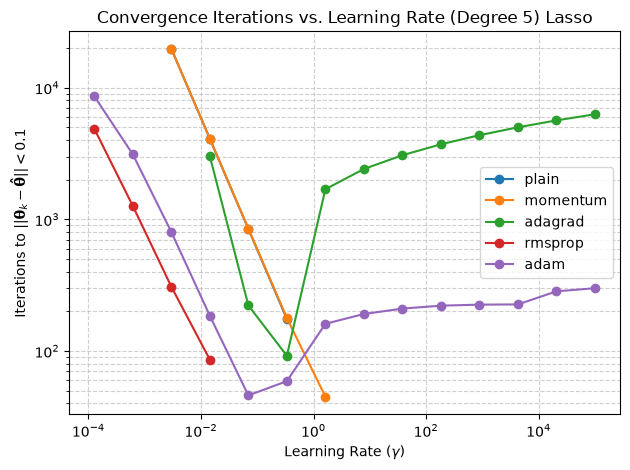

In [15]:
#g Lasso

import sklearn
def gradient_lasso(theta, X, y, lam=0.0):
    """simple lasso gradient"""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + lam * np.sign(theta)

lbd = 0.001

num = 20
gammas = np.logspace(-8,5,num)

lasso_model = sklearn.linear_model.Lasso(alpha = lbd)

theta_exact_5 = lasso_model.fit(X5,y5).coef_

#Resten skrevet av Gemini, jeg modifiserte det for Lasso regression i stedet for OLS.
grad_5_fn = lambda theta: gradient_lasso(theta, X5, y5, lam = lbd)
max_iters = 20000
target_tol = 0.1

methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
for method in methods:
    iterations_to_target = np.zeros(num)
    
    for i, gamma in enumerate(gammas):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient tolerance
        history, _ = optimise(grad_5_fn, theta0, method, gamma, num_iters=max_iters, tol=0)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan

    plt.loglog(gammas, iterations_to_target, marker="o", label=method)

plt.xlabel(r"Learning Rate ($\gamma$)")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 0.1$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5) Lasso")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:28: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:28: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\numpy\linalg\_linalg.py:2804: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\3845250652.py:8: RuntimeWarning: overflow encountered in multiply
  z = theta - gamma * g
C:\Users\Jon\

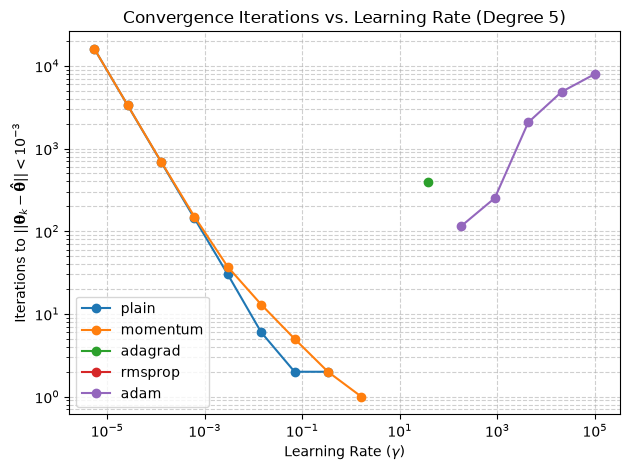

In [16]:


#g Lasso advanced

#Denne funksjonen er kopiert fra ChatGPT sin funksjon
def optimiser_step_lasso(method, theta, g, state, t, gamma, lam, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):

    if method == "plain":
        z = theta - gamma * g

    elif method == "momentum":
        v = state.get("v", np.zeros_like(theta))
        v = beta * v + (1 - beta) * g
        state["v"] = v

        z = theta - gamma*v

    elif method == "adagrad":
        r = state.get("r", np.zeros_like(theta))
        r = r + g**2
        state["r"] = r

        z = theta - gamma * g / np.sqrt(eps + r)

    elif method == "rmsprop":
        r = state.get("r", np.zeros_like(theta))
        r = rho * r + (1 - rho) * g**2
        state["r"] = r

        z = theta - gamma * g / np.sqrt(r + eps)

    elif method == "adam":
        m = state.get("m", np.zeros_like(theta))
        r = state.get("r", np.zeros_like(theta))

        m = beta1 * m + (1 - beta1) * g
        r = beta2 * r + (1 - beta2) * g**2

        state["m"] = m
        state["r"] = r

        # Bias correction
        m_hat = m / (1 - beta1**t)
        r_hat = r / (1 - beta2**t)

        z = theta - gamma * m_hat / (np.sqrt(r_hat) + eps)

    else:
        raise ValueError(f"unknown method {method}")

    #Apply Lasso so coefficients can get to exactly 0
    
    return np.sign(z)*np.maximum(np.abs(z)-lam*gamma, 0), state #<- ChatGPT fikset maximum i stedet for max


def optimise_lasso(grad, theta0, method, gamma, lam, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step_lasso(method, theta, g, state, t, gamma, lam = lam)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

lbd = 0.001

num = 20
gammas = np.logspace(-8,5,num)

lasso_model = sklearn.linear_model.Lasso(alpha = n*lbd)

theta_exact_5 = lasso_model.fit(X5,y5).coef_

#Resten skrevet av gemini med litt input fra meg:
grad_5_fn = lambda theta: gradient(theta, X5, y5, lam = lbd) #<- ChatGPT fikset gradient i stedet for gradient_lasso
max_iters = 20000
target_tol = 0.1

methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
for method in methods:
    iterations_to_target = np.zeros(num)
    
    for i, gamma in enumerate(gammas):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient tolerance
        history, _ = optimise_lasso(grad_5_fn, theta0, method, gamma, lam = lbd, num_iters=max_iters, tol=0)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan
            idx = np.argmin(distances)

    plt.loglog(gammas, iterations_to_target, marker="o", label=method)

plt.xlabel(r"Learning Rate ($\gamma$)")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
#h
#denne koden var kopiert fra oppgavesiden fra ukesoppgave 38
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0/(t+t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch],y[batch],lam) # the gradient of the cost on this minibatch
            gamma_t = step_length(t, schedule[0], schedule[1]) if schedule is not None else gamma               # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
            history.append(theta.copy())
    return np.array(history)

In [18]:
gamma_schedule = (0.1,10)
X2, y2 = exercise_data(degree=2, n = 100)
X5, y5 = exercise_data(degree=5, n = 100)
history = sgd(X5, y5, "momentum", n_epochs = 300, batch_size = 5, gamma = 0.0005)#, schedule = (10,10))
print(history[-1])
print(closed_form(X5, y5, 0))
print(np.linalg.norm(history[-1]-closed_form(X5,y5, 0)))

[ 0.07419211 -0.22473432  0.00856423  0.00373981 -0.04953472]
[-0.05254648 -0.65788157  0.41673487  0.42436608 -0.32802114]
0.7904199029994958


C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\1858096700.py:43: RuntimeWarning: overflow encountered in square
  mse[j][i] = np.mean((y2 - X5@history[-1])**2)
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:45: RuntimeWarning: overflow encountered in multiply
  return theta - gamma * g, state
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:28: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:28: RuntimeWarning: invalid value encountered in multiply
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:28: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\Jon\AppData\Local\Temp\ipykernel_19204\310669615.py:52: RuntimeWarning: overflow encountered in multiply
  return theta - gamma*v, state


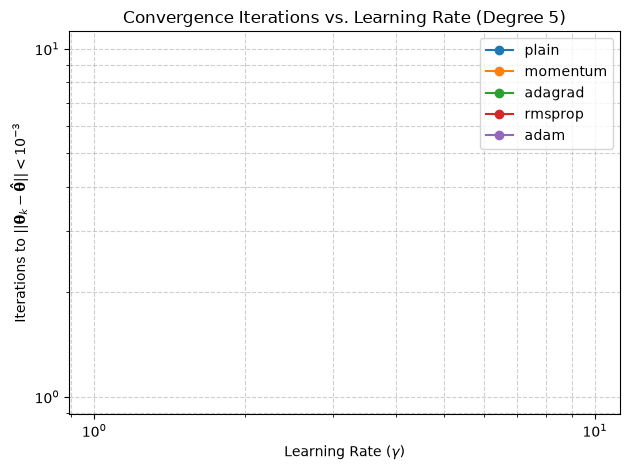

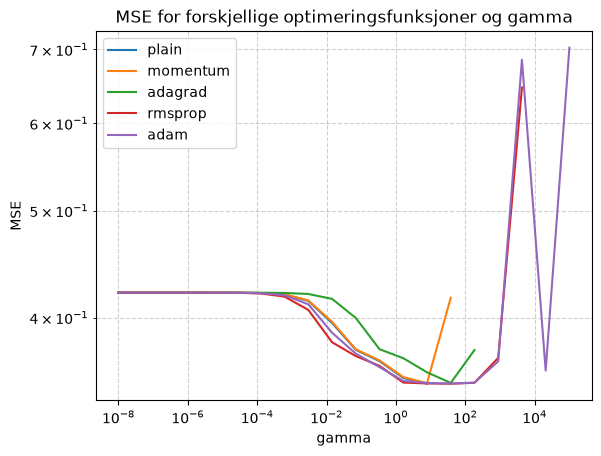

In [19]:
#h
X2, y2 = exercise_data(degree=2, n = 100)
X5, y5 = exercise_data(degree=5, n = 100)

num = 20
gammas = np.logspace(-8,5,num)
n_epochs = 1000
batch_size = 5


#Vary the learning rate:
max_iters = 20000
target_tol = 0.001
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

mse = np.zeros((len(methods), num))


grad_5_fn = lambda theta: gradient(theta, X5, y5, lam=0.0)
theta_exact_5 = closed_form(X5, y5, 0.0)
for j, method in enumerate (methods):
    iterations_to_target = np.zeros(num)
    
    for i, gamma in enumerate(gammas):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient 
        gamma_schedule = (gamma, 10)
        history = sgd(X5, y5, method, n_epochs = n_epochs, batch_size = batch_size, schedule=gamma_schedule)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan

        mse[j][i] = np.mean((y2 - X5@history[-1])**2)
        if mse[j][i] >1:
            mse[j][i] = np.nan

    plt.loglog(gammas, iterations_to_target, marker="o", label=method)

plt.xlabel(r"Learning Rate ($\gamma$)")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

for i, method in enumerate(methods):
    plt.loglog(gammas, mse[i,:])
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.title("MSE for forskjellige optimeringsfunksjoner og gamma")
plt.legend(methods)
plt.xlabel("gamma")
plt.ylabel("MSE")
plt.show()
    

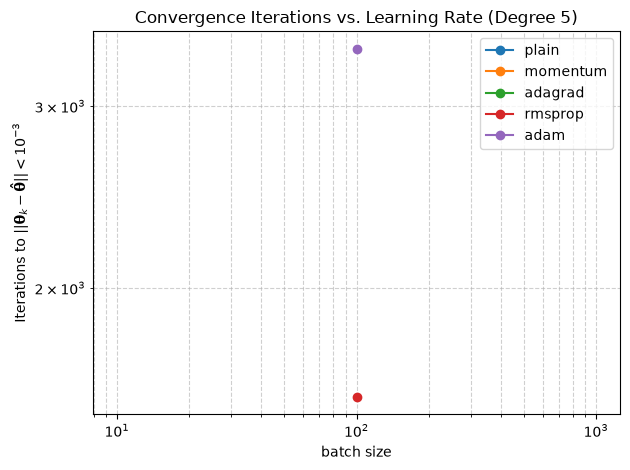

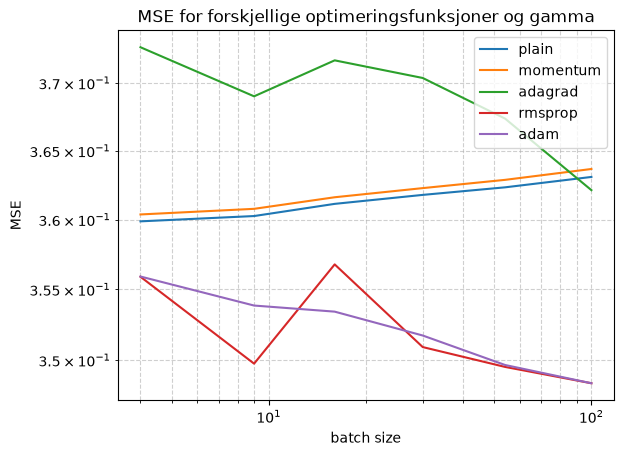

In [20]:
#h
X2, y2 = exercise_data(degree=2, n = 100)
X5, y5 = exercise_data(degree=5, n = 100)

num = 6
n_epochs = 10000
batch_sizes = np.int32(np.exp(np.linspace(np.log(5), np.log(n), num)))
gamma = 0.5

#Vary the learning rate:
max_iters = 20000
target_tol = 0.001
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

mse = np.zeros((len(methods), num))


grad_5_fn = lambda theta: gradient(theta, X5, y5, lam=0.0)
theta_exact_5 = closed_form(X5, y5, 0.0)
for j, method in enumerate (methods):
    iterations_to_target = np.zeros(num)
    
    for i, batch_size in enumerate(batch_sizes):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient 
        gamma_schedule = (gamma, 10)
        history = sgd(X5, y5, method, n_epochs = n_epochs, batch_size = batch_size, schedule=gamma_schedule)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan

        mse[j][i] = np.mean((y2 - X5@history[-1])**2)
        if mse[j][i] >1:
            mse[j][i] = np.nan

    plt.loglog(batch_sizes, iterations_to_target, marker="o", label=method)

plt.xlabel(r"batch size")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

for i, method in enumerate(methods):
    plt.loglog(batch_sizes, mse[i,:])
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.title("MSE for forskjellige optimeringsfunksjoner og gamma")
plt.legend(methods)
plt.xlabel("batch size")
plt.ylabel("MSE")
plt.show()
    

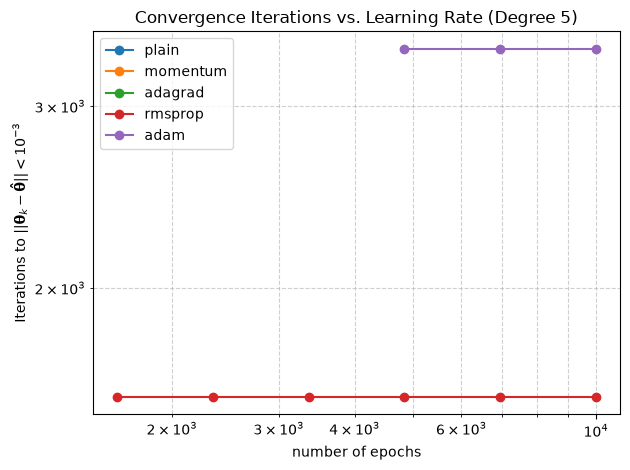

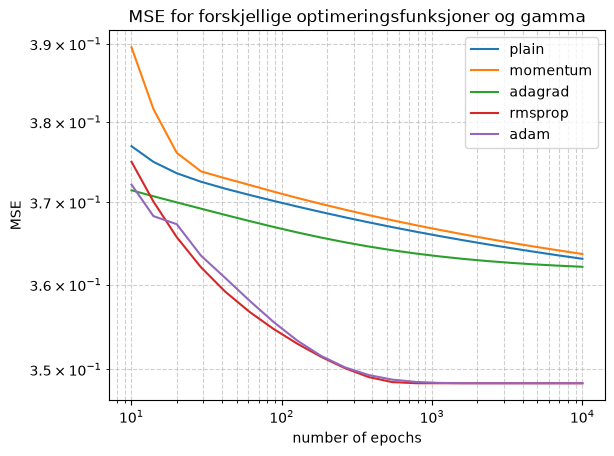

In [21]:
#h
X2, y2 = exercise_data(degree=2, n = 100)
X5, y5 = exercise_data(degree=5, n = 100)

num = 20
max_epochs = 10000
min_epochs = 10
n_epochs_list = np.int32(np.exp(np.linspace(np.log(min_epochs), np.log(max_epochs), num)))
gamma = 0.5
batch_sizes = 5


#Vary the learning rate:
max_iters = 20000
target_tol = 0.001
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

mse = np.zeros((len(methods), num))


grad_5_fn = lambda theta: gradient(theta, X5, y5, lam=0.0)
theta_exact_5 = closed_form(X5, y5, 0.0)
for j, method in enumerate (methods):
    iterations_to_target = np.zeros(num)
    
    for i, n_epochs in enumerate(n_epochs_list):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient 
        gamma_schedule = (gamma, 10)
        history = sgd(X5, y5, method, n_epochs = n_epochs, batch_size = batch_size, schedule=gamma_schedule)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan

        mse[j][i] = np.mean((y2 - X5@history[-1])**2)
        if mse[j][i] >1:
            mse[j][i] = np.nan

    plt.loglog(n_epochs_list, iterations_to_target, marker="o", label=method)

plt.xlabel(r"number of epochs")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

for i, method in enumerate(methods):
    plt.loglog(n_epochs_list, mse[i,:])
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.title("MSE for forskjellige optimeringsfunksjoner og gamma")
plt.legend(methods)
plt.xlabel("number of epochs")
plt.ylabel("MSE")
plt.show()
    

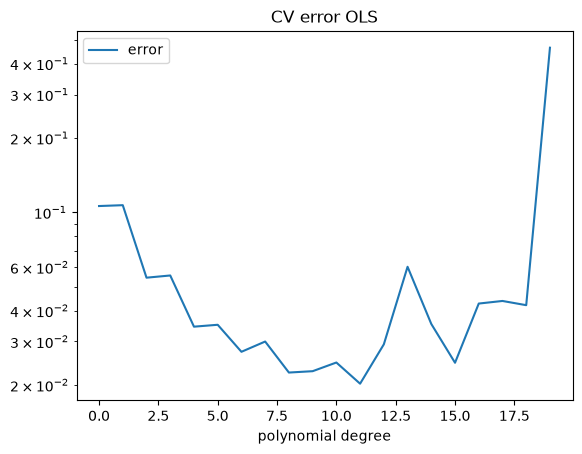

min error:  0.02023726542600979
degree with min error:  11


c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.468717413701428e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.188190994907857e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.039367202587842e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.2381788351582635e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\User

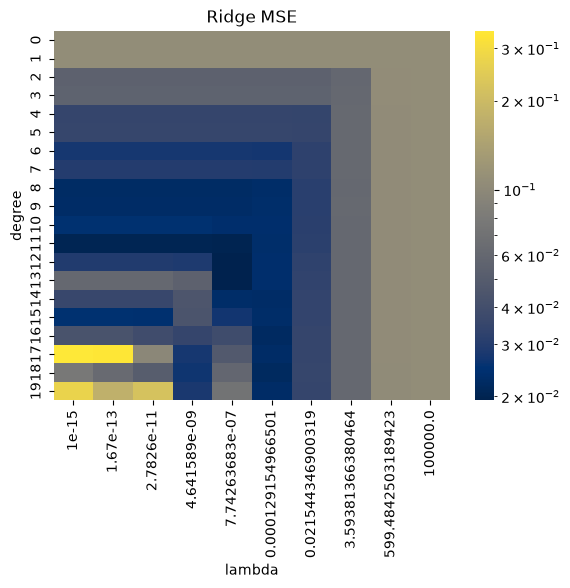

min error:  0.019383148565503164
degree with min error:  13
minimum lambda:  4


c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.653249e+00, tolerance: 9.336e-04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Jon\anaconda3\envs\jaxenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.188816e+00, tolerance: 8.382e-04
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.l

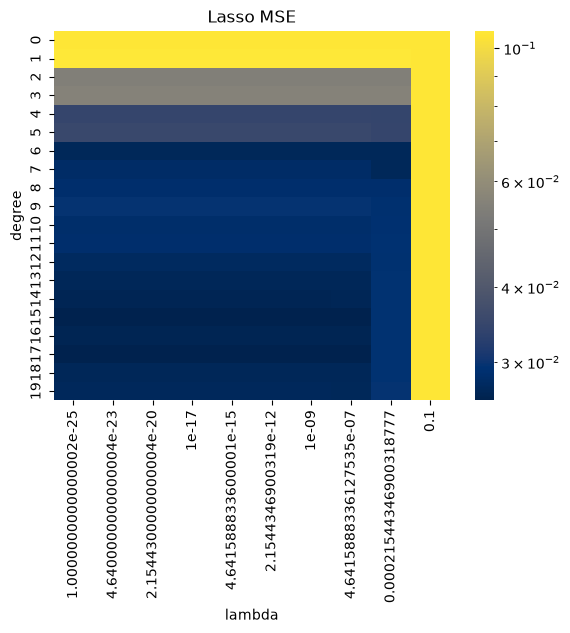

min error:  0.025909371841836337
degree with min error:  15
minimum lambda:  2


In [50]:
#i
#from sklearn.model_selection import train_test_split, KFold, cross_val_score
import seaborn as sns
from matplotlib.colors import LogNorm
from sklearn.linear_model import Lasso

np.random.seed(2026)

maxdegree = 20
splits = 10
num = 10

kf = KFold(n_splits = splits, shuffle = True, random_state=2026)

MSE = np.zeros(maxdegree)

#OLS:
for deg in range(maxdegree):
    mse = np.zeros(splits)

    model = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept= False))

    for i, (train_idx, test_idx) in enumerate(kf.split(x)):
        y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
        y_test = y[test_idx]

        mse[i] = np.mean((y_pred-y_test)**2)

    MSE[deg] = np.mean(mse)

x_axis = np.arange(maxdegree)
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.title("CV error OLS")
plt.plot(x_axis, MSE)
plt.legend(["error"])

plt.show()
min_error_OLS = np.min(MSE)
print("min error: ", min_error_OLS)
print("degree with min error: ",np.argmin(MSE))

#Ridge:

MSE_Ridge = np.zeros((maxdegree, num))
lambdas = np.logspace(-15,5, num)
for a, lbd in enumerate(lambdas):
    for deg in range(maxdegree):
        mse = np.zeros(splits)

        model = make_pipeline(PolynomialFeatures(degree = deg), Ridge(alpha = lbd))

        for i, (train_idx, test_idx) in enumerate(kf.split(x)):
            y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
            y_test = y[test_idx]

            mse[i] = np.mean((y_pred-y_test)**2)

        MSE_Ridge[deg, a] = np.mean(mse)
sns.heatmap(MSE_Ridge, norm = LogNorm(), xticklabels = np.round(lambdas, 15), cmap = "cividis")
plt.title("Ridge MSE")
plt.xlabel("lambda")
plt.ylabel("degree")

plt.show()
min_error_Ridge = np.min(MSE_Ridge)
print("min error: ",min_error_Ridge)
min_idx_ridge = np.argmin(MSE_Ridge)
min_degree_ridge = int(min_idx_ridge/num)
min_lambda_ridge = min_idx_ridge%num
print("degree with min error: ",min_degree_ridge)
print("minimum lambda: ", min_lambda_ridge)

#Lasso:
MSE_Lasso = np.zeros((maxdegree, num))
lambdas = np.logspace(-25,-1, num)
for a, lbd in enumerate(lambdas):
    for deg in range(maxdegree):
        mse = np.zeros(splits)

        model = make_pipeline(PolynomialFeatures(degree = deg), Lasso(alpha = lbd))

        for i, (train_idx, test_idx) in enumerate(kf.split(x)):
            y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
            y_test = y[test_idx]

            mse[i] = np.mean((y_pred-y_test)**2)

        MSE_Lasso[deg, a] = np.mean(mse)

sns.heatmap(MSE_Lasso, norm = LogNorm(), xticklabels = np.round(lambdas, 25), cmap = "cividis")
plt.title("Lasso MSE")
plt.xlabel("lambda")
plt.ylabel("degree")

plt.show()
min_error_Lasso = np.min(MSE_Lasso)
print("min error: ",min_error_Lasso)
min_idx_lasso = np.argmin(MSE_Lasso)
min_degree_lasso = int(min_idx_lasso/num)
min_lambda_lasso = min_idx_lasso%num
print("degree with min error: ",min_degree_lasso)
print("minimum lambda: ", min_lambda_lasso)

errors = np.array([min_error_OLS, min_error_Ridge, min_error_Lasso] )
best_optimiser = np.argmin(errors)

if best_optimiser == 0:
    best_model = model = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept= False))
    best_model.fit(x.reshape(-1,1), y)

elif best_optimiser == 1:
    best_model = model = make_pipeline(PolynomialFeatures(degree = deg), Ridge(alpha = min_lambda_ridge))
    best_model.fit(x.reshape(-1,1), y)

elif best_optimiser == 2:
    best_model = model = make_pipeline(PolynomialFeatures(degree = deg), Lasso(alpha = min_lambda_lasso))
    best_model.fit(x.reshape(-1,1), y) 